In [4]:
import pandas as pd
import plotly.express as px

df3_mat = pd.read_csv("student-mat.csv", sep=",")
df3_mat["G3"] = df3_mat["G3"] / 2
df3_mat = df3_mat[["Walc", "Dalc", "G3"]]
df3_por = pd.read_csv("student-por.csv", sep=",")
df3_por["G3"] = df3_por["G3"] / 2
df3_por = df3_por[["Walc", "Dalc", "G3"]]

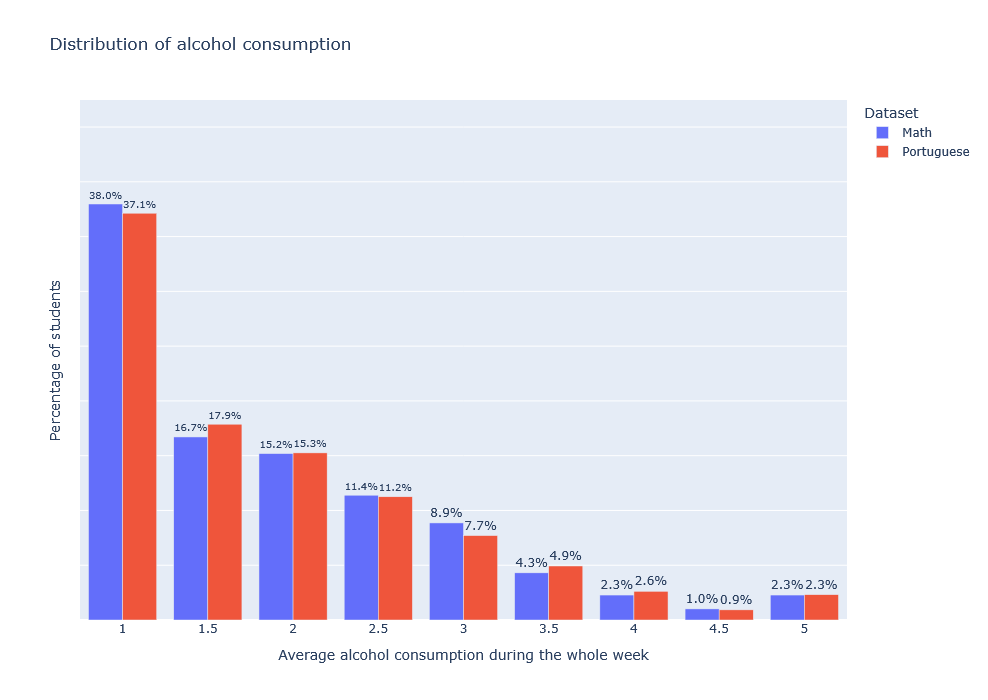

In [7]:
# Gemiddelde alcoholconsumptie berekenen
df3_mat["Alcohol"] = (df3_mat["Dalc"] + df3_mat["Walc"]) / 2
df3_por["Alcohol"] = (df3_por["Dalc"] + df3_por["Walc"]) / 2

# Relatieve frequenties berekenen
counts_mat = (
    df3_mat["Alcohol"]
    .value_counts(normalize=True)
    .sort_index()
)

counts_por = (
    df3_por["Alcohol"]
    .value_counts(normalize=True)
    .sort_index()
)

# Alle mogelijke alcoholscores verzamelen
all_scores = sorted(
    set(counts_mat.index).union(set(counts_por.index))
)

# DataFrame maken
counts = pd.DataFrame({
    "Alcohol": all_scores,
    "Math": counts_mat.reindex(all_scores, fill_value=0).values,
    "Portuguese": counts_por.reindex(all_scores, fill_value=0).values
})

# Omzetten naar long format voor Plotly
counts_long = counts.melt(
    id_vars="Alcohol",
    var_name="Dataset",
    value_name="Verhouding"
)

# Grafiek maken
fig = px.bar(
    counts_long,
    x="Alcohol",
    y="Verhouding",
    color="Dataset",
    barmode="group",
    text="Verhouding",
    labels={
        "Alcohol": "Average alcohol consumption during the whole week",
        "Verhouding": "Percentage of students"
    },
    title="Distribution of alcohol consumption"
)

fig.update_traces(
    texttemplate="%{y:.1%}",
    textposition="outside"
)

fig.update_layout(
    width=1000,
    height=700,
    yaxis_range=[0, counts_long["Verhouding"].max() * 1.25]
)

fig.update_yaxes(
    showticklabels=False,
    title="Percentage of students"
)

fig.show()